In [1]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [5]:
documents = [
    "Machine learning is a subset of artificial intelligence",
    "Deep learning uses neural networks",
    "Artificial intelligence is transforming industries",
    "Cats sleep most of the day",
    "Dogs enjoy playing in the park"
]

documents

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(documents)


print(f'Document Vocabulary: {tfidf.get_feature_names_out()}')
print("--------------------------------")
print(f'Features: {X_tfidf.shape[0]}, Vocabulary Size: {X_tfidf.shape[1]}')


Document Vocabulary: ['artificial' 'cats' 'day' 'deep' 'dogs' 'enjoy' 'in' 'industries'
 'intelligence' 'is' 'learning' 'machine' 'most' 'networks' 'neural' 'of'
 'park' 'playing' 'sleep' 'subset' 'the' 'transforming' 'uses']
--------------------------------
Features: 5, Vocabulary Size: 23


In [10]:
query = "How does machine learning work?"

query_vec = tfidf.transform([query])

scores = cosine_similarity(query_vec, X_tfidf)[0]

results_tfidf = pd.DataFrame({
    "Document": documents,
    "TF-IDF Similarity": scores
}).sort_values(by="TF-IDF Similarity", ascending=False)

results_tfidf


,Document,TF-IDF Similarity
0,Machine learning is a subset of artificial int...,0.560523
1,Deep learning uses neural networks,0.234906
2,Artificial intelligence is transforming indust...,0.000000
3,Cats sleep most of the day,0.000000
4,Dogs enjoy playing in the park,0.000000


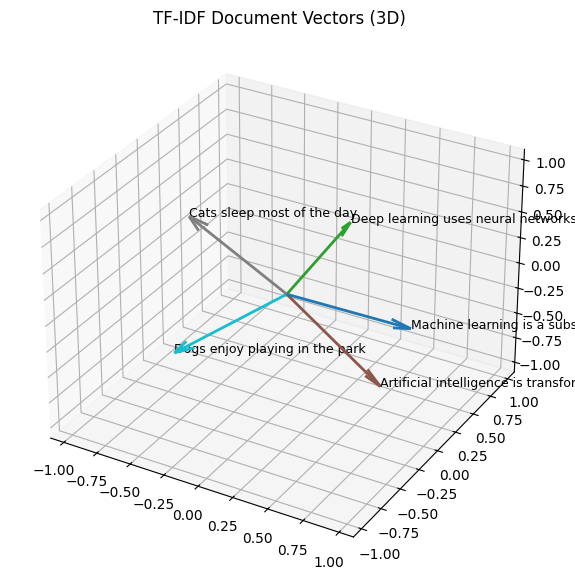

In [11]:
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_tfidf.toarray())
X_3d = normalize(X_3d)


fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

colors = plt.cm.tab10(np.linspace(0,1,len(documents)))

for i, doc in enumerate(documents):
    ax.quiver(
        0, 0, 0,
        X_3d[i,0], X_3d[i,1], X_3d[i,2],
        color=colors[i],
        arrow_length_ratio=0.15,
        linewidth=2
    )
    ax.text(X_3d[i,0], X_3d[i,1], X_3d[i,2], doc, fontsize=9)

ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
ax.set_zlim([-1.1,1.1])
ax.set_title("TF-IDF Document Vectors (3D)")

plt.show()


In [14]:
# Ranked Retrieval (Top-K)

def semantic_search_tfidf(query, documents, vectorizer, doc_vectors, top_k=3):
    query_vec = vectorizer.transform([query])
    scores = cosine_similarity(query_vec, doc_vectors)[0]
    
    results = sorted(
        zip(documents, scores),
        key=lambda x: x[1],
        reverse=True
    )
    return results[:top_k]


In [ ]:
# Chunking

long_text = """

Machine learning is a subset of artificial intelligence.
It focuses on building systems that learn from data.
Deep learning is a specialized form of machine learning.
Neural networks are used extensively in deep learning.

"""

chunks = long_text.strip().split(".")
chunks = [c.strip() for c in chunks if c.strip()]
chunks


['Machine learning is a subset of artificial intelligence',
 'It focuses on building systems that learn from data',
 'Deep learning is a specialized form of machine learning',
 'Neural networks are used extensively in deep learning']

In [15]:
tfidf_chunks = TfidfVectorizer()
X_chunks = tfidf_chunks.fit_transform(chunks)

semantic_search_tfidf(
    "neural networks",
    chunks,
    tfidf_chunks,
    X_chunks
)


[('Neural networks are used extensively in deep learning',
  np.float64(0.5334185723684125)),
 ('Machine learning is a subset of artificial intelligence', np.float64(0.0)),
 ('It focuses on building systems that learn from data', np.float64(0.0))]